In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# 常见中文字体
mpl.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'Noto Sans CJK SC']
mpl.rcParams['axes.unicode_minus'] = False 

In [4]:
# 加载导出的 npz
path = "./Dataset/eeg_epochs_4class_0to6s.npz"
d = np.load(path, allow_pickle=True)
X = d["X"]      # (N, C, T)
y = d["y"]      # (N,)
sfreq = float(d["sfreq"])
ch_names = d["ch_names"]

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype, "classes:", np.unique(y))
print("sfreq:", sfreq)

X: (548, 64, 1501) float32
y: (548,) int64 classes: [0 1 2 3]
sfreq: 250.0


In [3]:
# # 划分训练/验证/测试（简单稳妥版）
# rng = np.random.default_rng(42)
# idx = np.arange(len(y))
# rng.shuffle(idx)
# 
# X = X[idx]
# y = y[idx]
# 
# n = len(y)
# n_train = int(0.7 * n)
# n_val   = int(0.15 * n)
# n_test  = n - n_train - n_val
# 
# X_train, y_train = X[:n_train], y[:n_train]
# X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
# X_test,  y_test  = X[n_train+n_val:], y[n_train+n_val:]
# 
# print("train/val/test:", len(y_train), len(y_val), len(y_test))

In [4]:
# 先切出 70% 训练 + 30% 临时集
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    shuffle=True,
    stratify=y
)

# 再把 30% 临时集切成 15% 验证 + 15% 测试
# 在临时集内部，验证占比 = 0.15 / 0.30 = 0.5
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp,
    test_size=0.50,
    random_state=42,
    shuffle=True,
    stratify=y_tmp
)

print("train/val/test:", len(y_train), len(y_val), len(y_test))
# 确认三份数据的类别
def show_counts(name, yy):
    u, c = np.unique(yy, return_counts=True)
    print(name, dict(zip(u, c)))

show_counts("train", y_train)
show_counts("val", y_val)
show_counts("test", y_test)

train/val/test: 383 82 83
train {0: 99, 1: 101, 2: 92, 3: 91}
val {0: 21, 1: 21, 2: 20, 3: 20}
test {0: 22, 1: 22, 2: 20, 3: 19}


In [5]:
# PyTorch Dataset / DataLoader
# 把 (N, C, T) 变成 (N, 1, C, T)，并转成 torch tensor。
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()          # (N, C, T)
        self.y = torch.from_numpy(y).long()           # (N,)
    def __len__(self):
        return self.y.shape[0]
    def __getitem__(self, i):
        x = self.X[i].unsqueeze(0)                    # (1, C, T)
        return x, self.y[i]

batch_size = 32
train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=batch_size, shuffle=True, drop_last=False)
val_loader   = DataLoader(EEGDataset(X_val, y_val),     batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(EEGDataset(X_test, y_test),   batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print("batch X:", xb.shape, "batch y:", yb.shape)

batch X: torch.Size([32, 1, 64, 1501]) batch y: torch.Size([32])


In [6]:
# EEGNet
# Conv2d(1→F1) 做时间卷积
# DepthwiseConv 做空间滤波（跨通道）
# SeparableConv 做特征提取
# 全局池化 + 分类

import torch
import torch.nn as nn
import torch.nn.functional as F

class EEGNet(nn.Module):
    def __init__(self, n_chans, n_times, n_classes,
                 F1=8, D=2, F2=16, 
                 kernel_length=125, 
                 dropout=0.25):
        super().__init__()
        self.n_chans = n_chans
        self.n_times = n_times

        # 1) Temporal Conv
        self.conv_temporal = nn.Conv2d(
            in_channels=1, out_channels=F1,
            kernel_size=(1, kernel_length),
            stride=1, padding=(0, kernel_length // 2),
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(F1)

        # 2) Depthwise Spatial Conv (across channels)
        self.conv_depthwise = nn.Conv2d(
            in_channels=F1, out_channels=F1 * D,
            kernel_size=(n_chans, 1),
            groups=F1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(F1 * D)
        self.pool1 = nn.AvgPool2d(kernel_size=(1, 4), stride=(1, 4))
        self.drop1 = nn.Dropout(dropout)

        # 3) Separable Conv
        self.conv_separable_depth = nn.Conv2d(
            in_channels=F1 * D, out_channels=F1 * D,
            kernel_size=(1, 16),
            padding=(0, 8),
            groups=F1 * D,
            bias=False
        )
        self.conv_separable_point = nn.Conv2d(
            in_channels=F1 * D, out_channels=F2,
            kernel_size=(1, 1),
            bias=False
        )
        self.bn3 = nn.BatchNorm2d(F2)
        self.pool2 = nn.AvgPool2d(kernel_size=(1, 4), stride=(1, 4))
        self.drop2 = nn.Dropout(dropout)

        # 新增：自适应全局池化，确保无论 n_times 多大/是否整除都能固定输出维度
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # 分类层：用一次 dummy forward 自动算 flatten 维度（你的实例化代码不变）
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_chans, n_times)
            out = self._forward_features(dummy)
            feat_dim = out.shape[1]
        self.classifier = nn.Linear(feat_dim, n_classes)

    def _forward_features(self, x):
        x = self.conv_temporal(x)
        x = self.bn1(x)
        x = F.elu(x)

        x = self.conv_depthwise(x)
        x = self.bn2(x)
        x = F.elu(x)
        x = self.pool1(x)
        x = self.drop1(x)

        x = self.conv_separable_depth(x)
        x = self.conv_separable_point(x)
        x = self.bn3(x)
        x = F.elu(x)
        x = self.pool2(x)
        x = self.drop2(x)

        # 新增：全局池化到 (B, F2, 1, 1)，再 flatten => (B, F2)
        x = self.gap(x)

        x = x.flatten(1)
        return x

    def forward(self, x):
        x = self._forward_features(x)
        x = self.classifier(x)
        return x


In [7]:
# 实例化并检查
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_chans = X.shape[1]
n_times = X.shape[2]
n_classes = len(np.unique(y))

model = EEGNet(n_chans=n_chans, n_times=n_times, n_classes=n_classes).to(device)
print(model)

# forward sanity check
model.eval()
with torch.no_grad():
    logits = model(xb.to(device))
print("logits:", logits.shape)

EEGNet(
  (conv_temporal): Conv2d(1, 8, kernel_size=(1, 125), stride=(1, 1), padding=(0, 62), bias=False)
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_depthwise): Conv2d(8, 16, kernel_size=(64, 1), stride=(1, 1), groups=8, bias=False)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
  (drop1): Dropout(p=0.25, inplace=False)
  (conv_separable_depth): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
  (conv_separable_point): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
  (drop2): Dropout(p=0.25, inplace=False)
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Linear(in_features=16, out_features=4, bias=True)
)

In [8]:
# 训练循环（含验证集准确率）
def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

def run_one_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for x, yb in loader:
        x = x.to(device)
        yb = yb.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(x)
            loss = criterion(logits, yb)

            if train:
                loss.backward()
                optimizer.step()

        bs = yb.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_from_logits(logits, yb) * bs
        total_n    += bs

    return total_loss / total_n, total_acc / total_n

import matplotlib.pyplot as plt
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

epochs = 100
best_val_acc = -1.0
best_state = None

for ep in range(1, epochs+1):
    tr_loss, tr_acc = run_one_epoch(train_loader, train=True)
    va_loss, va_acc = run_one_epoch(val_loader, train=False)

    # 新增：记录
    train_losses.append(tr_loss); val_losses.append(va_loss)
    train_accs.append(tr_acc);    val_accs.append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {ep:02d} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {va_loss:.4f} acc {va_acc:.3f}")

print("best val acc:", best_val_acc)


Epoch 01 | train loss 1.4003 acc 0.243 | val loss 1.3941 acc 0.244
Epoch 02 | train loss 1.3946 acc 0.248 | val loss 1.3884 acc 0.244
Epoch 03 | train loss 1.3882 acc 0.256 | val loss 1.3821 acc 0.280
Epoch 04 | train loss 1.3847 acc 0.261 | val loss 1.3764 acc 0.293
Epoch 05 | train loss 1.3792 acc 0.261 | val loss 1.3728 acc 0.256
Epoch 06 | train loss 1.3755 acc 0.319 | val loss 1.3662 acc 0.341
Epoch 07 | train loss 1.3728 acc 0.332 | val loss 1.3606 acc 0.354
Epoch 08 | train loss 1.3647 acc 0.366 | val loss 1.3559 acc 0.341
Epoch 09 | train loss 1.3625 acc 0.373 | val loss 1.3514 acc 0.354
Epoch 10 | train loss 1.3541 acc 0.392 | val loss 1.3438 acc 0.341
Epoch 11 | train loss 1.3482 acc 0.363 | val loss 1.3400 acc 0.354
Epoch 12 | train loss 1.3445 acc 0.347 | val loss 1.3352 acc 0.317
Epoch 13 | train loss 1.3341 acc 0.389 | val loss 1.3325 acc 0.317
Epoch 14 | train loss 1.3285 acc 0.413 | val loss 1.3323 acc 0.305
Epoch 15 | train loss 1.3141 acc 0.420 | val loss 1.3292 acc 0

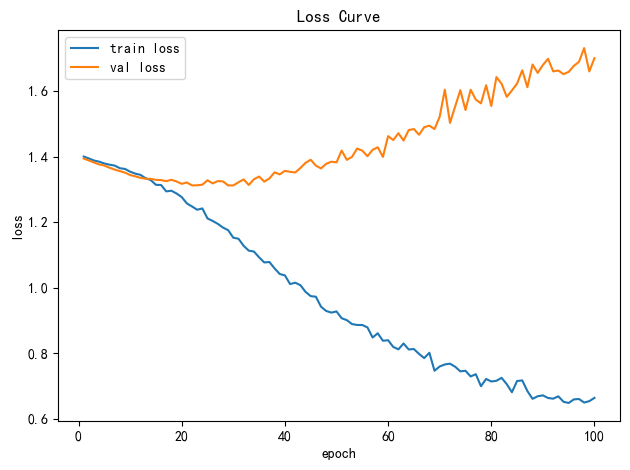

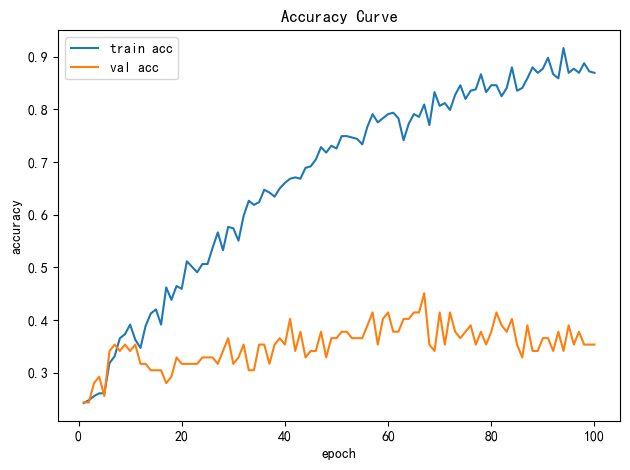

In [9]:
epochs_r = np.arange(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs_r, train_losses, label="train loss")
plt.plot(epochs_r, val_losses, label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig("损失曲线_loss_curve（dropout=0.25）sk_2.png", dpi=300, bbox_inches="tight")  # 保存
plt.show()

plt.figure()
plt.plot(epochs_r, train_accs, label="train acc")
plt.plot(epochs_r, val_accs, label="val acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.tight_layout()
plt.savefig("准确率曲线_accuracy_curve（dropout=0.25）sk_2.png", dpi=300, bbox_inches="tight")
plt.show()


In [10]:
# 加载最佳模型并跑测试集：
model.load_state_dict(best_state)
te_loss, te_acc = run_one_epoch(test_loader, train=False)
print("test loss:", te_loss, "test acc:", te_acc)

test loss: 1.7608449617064144 test acc: 0.3012048217905573


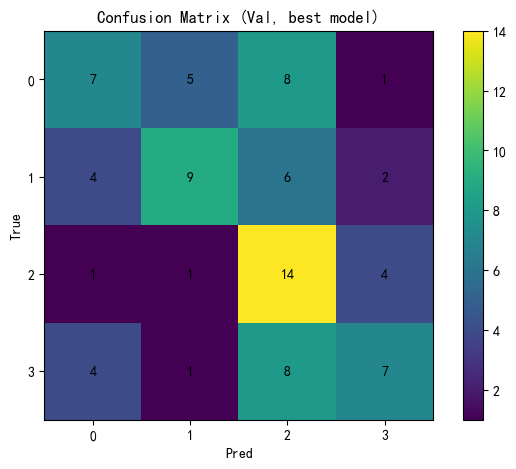

In [11]:
# 输出混淆矩阵
def predict_all(loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for x, yb in loader:
            logits = model(x.to(device))
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            ys.append(yb.numpy())
            ps.append(pred)
    return np.concatenate(ys), np.concatenate(ps)

# 加载最好模型
model.load_state_dict(best_state)

y_true, y_pred = predict_all(val_loader)
K = len(np.unique(y_true))

cm = np.zeros((K, K), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

plt.figure()
plt.imshow(cm)
plt.xlabel("Pred")
plt.ylabel("True")
plt.title("Confusion Matrix (Val, best model)")
plt.colorbar()
plt.xticks(range(K))
plt.yticks(range(K))
# 在格子里写数字
for i in range(K):
    for j in range(K):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.savefig("混淆矩阵_confusion_matrix_val_annotated（dropout=0.25）sk_2.png", dpi=300, bbox_inches="tight")
plt.show()



In [12]:
print("val true counts:", np.bincount(y_true, minlength=K))
print("val pred counts:", np.bincount(y_pred, minlength=K))


val true counts: [21 21 20 20]
val pred counts: [16 16 36 14]


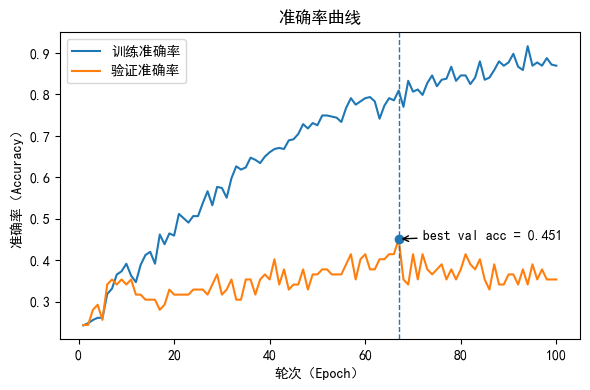

In [13]:
best_val_acc = float(np.max(val_accs))
best_epoch = int(np.argmax(val_accs) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs_r, train_accs, label="训练准确率")
plt.plot(epochs_r, val_accs, label="验证准确率")

# 画出最佳点
plt.scatter([best_epoch], [best_val_acc], zorder=3)
plt.axvline(best_epoch, linestyle="--", linewidth=1)

# 标注文字（显示 best val acc）
plt.annotate(
    f"best val acc = {best_val_acc:.3f}",
    xy=(best_epoch, best_val_acc),
    xytext=(best_epoch + max(2, len(epochs_r)//20), best_val_acc),
    arrowprops=dict(arrowstyle="->", linewidth=1)
)

plt.xlabel("轮次（Epoch）")
plt.ylabel("准确率（Accuracy）")
plt.title("准确率曲线")
plt.legend()
plt.tight_layout()
plt.savefig("准确率曲线_accuracy_curve（dropout=0.25）sk_2.png", dpi=300, bbox_inches="tight")
plt.show()
